In [1]:
!pip install pyspark -q
print("✅ PySpark installed")

✅ PySpark installed


In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os, gzip, shutil, zipfile

base = "/content/drive/MyDrive/MovieAnalytics"

# Extract .gz IMDb files
for gz in ["title.ratings.tsv.gz","title.basics.tsv.gz","name.basics.tsv.gz","title.principals.tsv.gz"]:
    src, dst = f"{base}/{gz}", f"{base}/{gz[:-3]}"
    if os.path.exists(dst): print(f"⏭️  {gz[:-3]} already extracted"); continue
    print(f"📦 Extracting {gz}...")
    with gzip.open(src,'rb') as fi, open(dst,'wb') as fo: shutil.copyfileobj(fi,fo)
    print(f"✅ {gz[:-3]} — {round(os.path.getsize(dst)/1024/1024,1)} MB")

# Extract ml-25m.zip
if not os.path.exists(f"{base}/ml-25m"):
    print("📦 Extracting ml-25m.zip...")
    with zipfile.ZipFile(f"{base}/ml-25m.zip",'r') as z: z.extractall(base)
    print("✅ ml-25m/ extracted!")
else:
    print("⏭️  ml-25m/ already extracted")

print("\n✅ All files ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏭️  title.ratings.tsv already extracted
⏭️  title.basics.tsv already extracted
⏭️  name.basics.tsv already extracted
⏭️  title.principals.tsv already extracted
📦 Extracting ml-25m.zip...
✅ ml-25m/ extracted!

✅ All files ready!


In [8]:
import os
b  = "/content/drive/MyDrive/MovieAnalytics"
b2 = f"{b}/ml-25m"

files = {
    "movies.csv":            b2,
    "ratings.csv":           b2,
    "title.basics.tsv":      b,
    "title.ratings.tsv":     b,
    "name.basics.tsv":       b,
    "title.principals.tsv":  b,
}

all_ok = True
for f, folder in files.items():
    path = f"{folder}/{f}"
    ok   = os.path.exists(path)
    size = round(os.path.getsize(path)/1024/1024, 1) if ok else 0
    if not ok: all_ok = False
    print(f"{'✅' if ok else '❌'} {f:30s} {size} MB")

print("\n✅ All good — proceed!" if all_ok else "\n❌ Fix missing files first!")

✅ movies.csv                     2.9 MB
✅ ratings.csv                    646.8 MB
✅ title.basics.tsv               1031.8 MB
✅ title.ratings.tsv              27.8 MB
✅ name.basics.tsv                901.9 MB
✅ title.principals.tsv           4229.2 MB

✅ All good — proceed!


In [9]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MovieTrendAnalytics") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"✅ Spark {spark.version} ready!")

✅ Spark 4.0.2 ready!


In [10]:
b  = "/content/drive/MyDrive/MovieAnalytics"
b2 = f"{b}/ml-25m"

print("Loading datasets... please wait")

movies    = spark.read.csv(f"{b2}/movies.csv",           header=True, inferSchema=True)
ratings   = spark.read.csv(f"{b2}/ratings.csv",          header=True, inferSchema=True)
imdb_bas  = spark.read.csv(f"{b}/title.basics.tsv",      header=True, inferSchema=True, sep="\t")
imdb_rat  = spark.read.csv(f"{b}/title.ratings.tsv",     header=True, inferSchema=True, sep="\t")
imdb_nam  = spark.read.csv(f"{b}/name.basics.tsv",       header=True, inferSchema=True, sep="\t")
imdb_prin = spark.read.csv(f"{b}/title.principals.tsv",  header=True, inferSchema=True, sep="\t")

print(f"✅ movies     : {movies.count():>10,} rows")
print(f"✅ ratings    : {ratings.count():>10,} rows")
print(f"✅ imdb_basics: {imdb_bas.count():>10,} rows")

Loading datasets... please wait
✅ movies     :     62,423 rows
✅ ratings    : 25,000,095 rows
✅ imdb_basics: 12,478,987 rows


In [11]:
movies.createOrReplaceTempView("movies")
ratings.createOrReplaceTempView("ratings")
imdb_bas.createOrReplaceTempView("imdb_basics")
imdb_rat.createOrReplaceTempView("imdb_ratings")
imdb_nam.createOrReplaceTempView("imdb_names")
imdb_prin.createOrReplaceTempView("imdb_principals")

print("✅ Hive tables registered:")
spark.sql("SHOW TABLES").show()

✅ Hive tables registered:
+---------+---------------+-----------+
|namespace|      tableName|isTemporary|
+---------+---------------+-----------+
|         |    imdb_basics|       true|
|         |     imdb_names|       true|
|         |imdb_principals|       true|
|         |   imdb_ratings|       true|
|         |         movies|       true|
|         |        ratings|       true|
+---------+---------------+-----------+



In [12]:
out = "/content/drive/MyDrive/MovieAnalytics"

genre_trends = spark.sql("""
    SELECT
        YEAR(FROM_UNIXTIME(r.timestamp))   AS rating_year,
        genre,
        COUNT(*)                            AS total_ratings,
        ROUND(AVG(r.rating), 2)             AS avg_rating
    FROM ratings r
    JOIN movies m ON r.movieId = m.movieId
    LATERAL VIEW explode(split(m.genres, '[|]')) g AS genre
    WHERE genre != '(no genres listed)'
      AND YEAR(FROM_UNIXTIME(r.timestamp)) BETWEEN 1995 AND 2019
    GROUP BY YEAR(FROM_UNIXTIME(r.timestamp)), genre
    ORDER BY rating_year, total_ratings DESC
""")

genre_trends.show(15)
genre_trends.toPandas().to_csv(f"{out}/genre_trends.csv", index=False)
print("✅ genre_trends.csv saved!")

+-----------+---------+-------------+----------+
|rating_year|    genre|total_ratings|avg_rating|
+-----------+---------+-------------+----------+
|       1995|   Comedy|            2|       3.0|
|       1995|    Crime|            2|       3.0|
|       1995| Thriller|            2|       4.0|
|       1995|  Mystery|            1|       5.0|
|       1996|    Drama|       615791|       3.7|
|       1996|   Comedy|       533845|      3.42|
|       1996| Thriller|       464795|       3.6|
|       1996|   Action|       435303|      3.44|
|       1996|Adventure|       316819|      3.48|
|       1996|  Romance|       315530|       3.6|
|       1996|    Crime|       256556|      3.62|
|       1996|   Sci-Fi|       168118|      3.42|
|       1996| Children|       150588|      3.51|
|       1996|  Fantasy|       121461|      3.48|
|       1996|Animation|        77603|       3.7|
+-----------+---------+-------------+----------+
only showing top 15 rows
✅ genre_trends.csv saved!


In [13]:
actor_director = spark.sql("""
    SELECT
        n.primaryName,
        p.category,
        COUNT(DISTINCT p.tconst)                        AS total_titles,
        ROUND(AVG(CAST(ir.averageRating AS FLOAT)), 2)  AS avg_imdb_rating,
        SUM(CAST(ir.numVotes AS INT))                   AS total_votes
    FROM imdb_principals p
    JOIN imdb_names   n  ON p.nconst  = n.nconst
    JOIN imdb_ratings ir ON p.tconst  = ir.tconst
    JOIN imdb_basics  ib ON p.tconst  = ib.tconst
    WHERE p.category IN ('actor','actress','director')
      AND CAST(ir.numVotes AS INT) > 50000
      AND ib.titleType = 'movie'
    GROUP BY n.primaryName, p.category
    HAVING COUNT(DISTINCT p.tconst) >= 3
    ORDER BY avg_imdb_rating DESC, total_votes DESC
    LIMIT 50
""")

actor_director.show(15)
actor_director.toPandas().to_csv(f"{out}/actor_director.csv", index=False)
print("✅ actor_director.csv saved!")

+---------------+--------+------------+---------------+-----------+
|    primaryName|category|total_titles|avg_imdb_rating|total_votes|
+---------------+--------+------------+---------------+-----------+
|    Kenny Baker|   actor|           3|           8.57|    3539525|
|   Peter Mayhew|   actor|           3|           8.53|    4280364|
|         Suriya|   actor|           3|            8.5|     455217|
|Sterling Hayden|   actor|           3|           8.47|    2881095|
|     Sala Baker|   actor|           3|           8.44|    8792211|
|    Lee J. Cobb|   actor|           3|            8.4|    1659460|
|Charles Chaplin|   actor|           5|           8.35|    1293948|
|Tatsuya Nakadai|   actor|           4|           8.35|     457285|
|   Sergio Leone|director|           5|           8.34|    2236997|
|Charles Chaplin|director|           5|           8.34|    1034564|
|  Frank Vincent|   actor|           3|           8.33|    2420099|
|    Henry Fonda|   actor|           4|         

In [14]:
rating_trends = spark.sql("""
    SELECT
        YEAR(FROM_UNIXTIME(timestamp))                                          AS rating_year,
        COUNT(*)                                                                AS total_ratings,
        ROUND(AVG(rating), 3)                                                   AS avg_rating,
        COUNT(DISTINCT userId)                                                  AS unique_users,
        COUNT(DISTINCT movieId)                                                 AS unique_movies,
        ROUND(SUM(CASE WHEN rating >= 4.0 THEN 1 ELSE 0 END)*100.0/COUNT(*),1) AS pct_high_ratings
    FROM ratings
    GROUP BY YEAR(FROM_UNIXTIME(timestamp))
    ORDER BY rating_year
""")

rating_trends.show()
rating_trends.toPandas().to_csv(f"{out}/rating_trends.csv", index=False)
print("✅ rating_trends.csv saved!")

+-----------+-------------+----------+------------+-------------+----------------+
|rating_year|total_ratings|avg_rating|unique_users|unique_movies|pct_high_ratings|
+-----------+-------------+----------+------------+-------------+----------------+
|       1995|            3|     3.667|           1|            3|            33.3|
|       1996|      1430093|     3.546|       23028|         1383|            48.9|
|       1997|       626202|     3.588|       10014|         1672|            51.7|
|       1998|       272099|     3.513|        3315|         2295|            54.5|
|       1999|      1059080|     3.617|        8387|         3026|            59.0|
|       2000|      1735398|     3.575|       13303|         3861|            57.3|
|       2001|      1058750|     3.532|        9300|         4712|            55.6|
|       2002|       776654|     3.486|        7098|         5722|            53.7|
|       2003|       920295|     3.477|        7674|         6806|            48.2|
|   

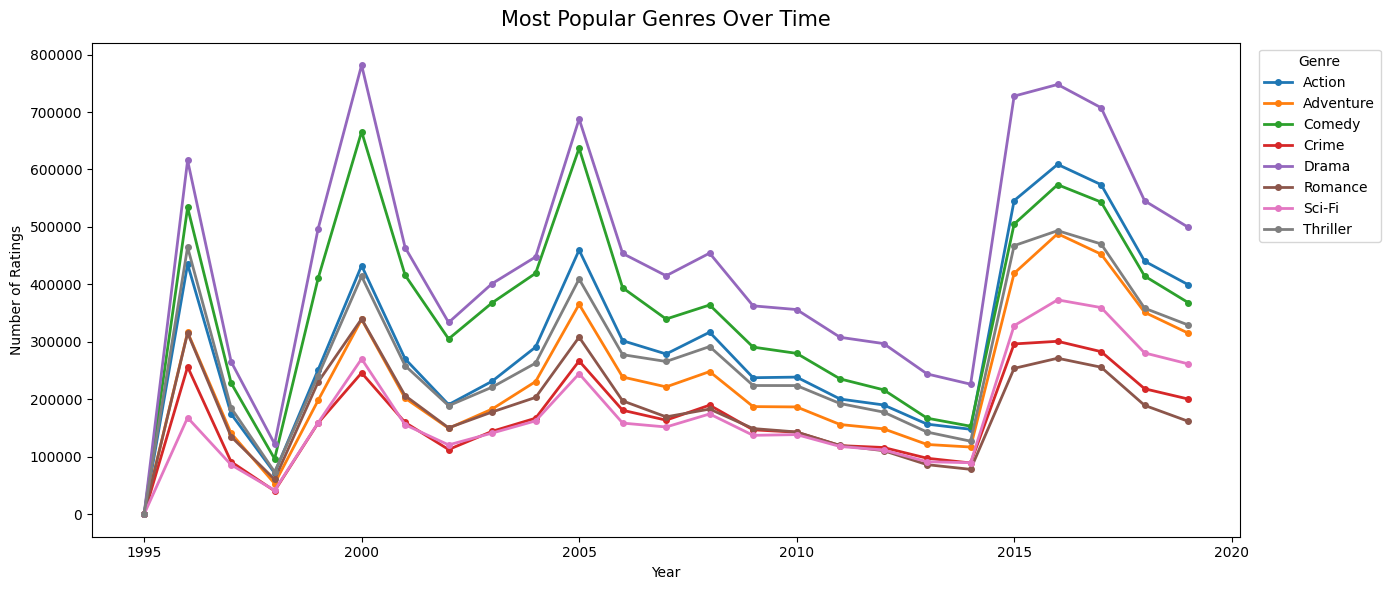

✅ Chart 1 saved!


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

out = "/content/drive/MyDrive/MovieAnalytics"
df  = pd.read_csv(f"{out}/genre_trends.csv")

top8  = df.groupby('genre')['total_ratings'].sum().nlargest(8).index
pivot = df[df['genre'].isin(top8)].pivot_table(
    index='rating_year', columns='genre', values='total_ratings', fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(ax=ax, linewidth=2, marker='o', markersize=4)
ax.set_title('Most Popular Genres Over Time', fontsize=15, pad=12)
ax.set_xlabel('Year'); ax.set_ylabel('Number of Ratings')
ax.legend(title='Genre', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(f"{out}/chart1_genre_trends.png", dpi=150)
plt.show()
print("✅ Chart 1 saved!")

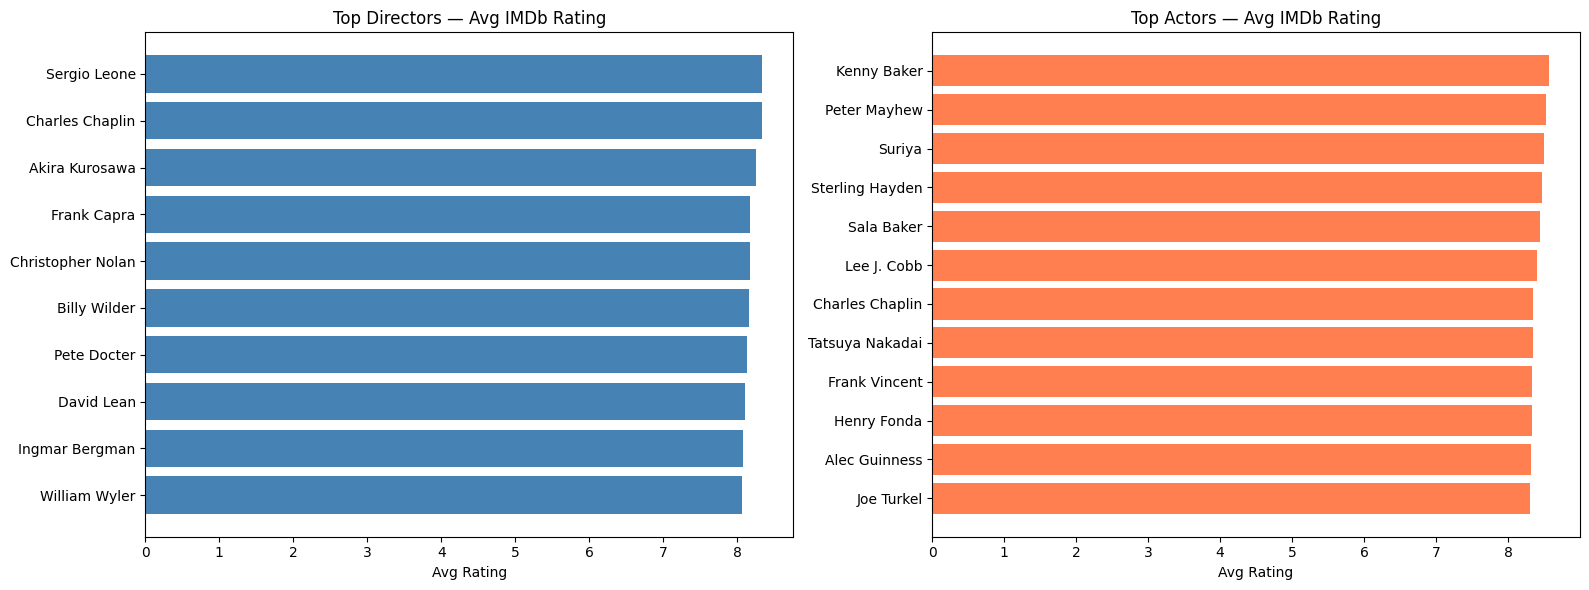

✅ Chart 2 saved!


In [16]:
df_p   = pd.read_csv(f"{out}/actor_director.csv")
df_dir = df_p[df_p['category'] == 'director'].nlargest(12, 'avg_imdb_rating')
df_act = df_p[df_p['category'].isin(['actor','actress'])].nlargest(12, 'avg_imdb_rating')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(df_dir['primaryName'], df_dir['avg_imdb_rating'], color='steelblue')
axes[0].set_title('Top Directors — Avg IMDb Rating')
axes[0].set_xlabel('Avg Rating'); axes[0].invert_yaxis()

axes[1].barh(df_act['primaryName'], df_act['avg_imdb_rating'], color='coral')
axes[1].set_title('Top Actors — Avg IMDb Rating')
axes[1].set_xlabel('Avg Rating'); axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{out}/chart2_actor_director.png", dpi=150)
plt.show()
print("✅ Chart 2 saved!")

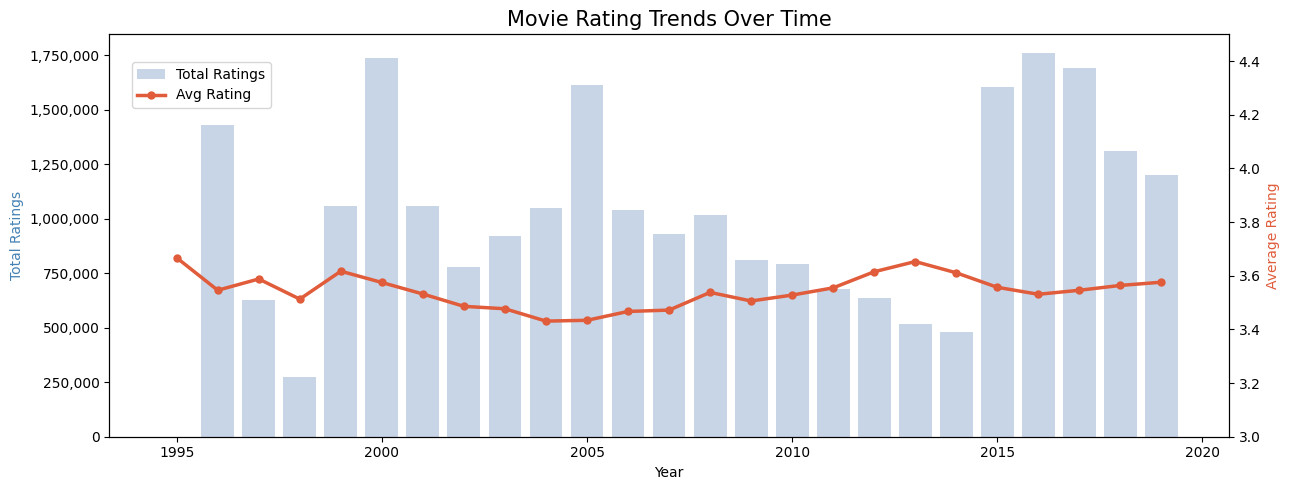

✅ Chart 3 saved!


In [17]:
import matplotlib.ticker as mticker

df_rt = pd.read_csv(f"{out}/rating_trends.csv")

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.bar(df_rt['rating_year'], df_rt['total_ratings'], color='#b0c4de', alpha=0.7, label='Total Ratings')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Ratings', color='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = ax1.twinx()
ax2.plot(df_rt['rating_year'], df_rt['avg_rating'], color='#e05c3a',
         linewidth=2.5, marker='o', markersize=5, label='Avg Rating')
ax2.set_ylabel('Average Rating', color='#e05c3a')
ax2.set_ylim(3.0, 4.5)

ax1.set_title('Movie Rating Trends Over Time', fontsize=15)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.savefig(f"{out}/chart3_rating_trends.png", dpi=150)
plt.show()
print("✅ Chart 3 saved!")